In [2]:
!pip install opencv-python numpy pandas tqdm pycryptodome


   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   --- ------------------------------------ 3.4/39.0 MB 18.9 MB/s eta 0:00:02
   --------- ------------------------------ 8.9/39.0 MB 22.3 MB/s eta 0:00:02
   -------------- ------------------------- 13.9/39.0 MB 22.7 MB/s eta 0:00:02
   ------------------ --------------------- 17.8/39.0 MB 21.6 MB/s eta 0:00:01
   ---------------------- ----------------- 22.3/39.0 MB 21.5 MB/s eta 0:00:01
   ------------------------------ --------- 29.9/39.0 MB 24.0 MB/s eta 0:00:01
   -------------------------------------- - 38.0/39.0 MB 26.2 MB/s eta 0:00:01
   ---------------------------------------- 39.0/39.0 MB 25.2 MB/s eta 0:00:00


In [3]:
import cv2
print("OpenCV version:", cv2.__version__)


OpenCV version: 4.12.0


In [ ]:
"""AES Encryption resolution 512x512"""

In [2]:
import cv2
import numpy as np
import os
import pandas as pd
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
from Crypto.Random import get_random_bytes

# --- PATH CONFIGURATIONS ---
INPUT_DIR = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\aerials\by_resolution\512x512"
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_512\Encrypted22.2"
DEC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_512\Decrypted22.2"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_Evaluation_512_22.2.xlsx"

# Ensure folders exist
for folder in [ENC_FOLDER, DEC_FOLDER]:
    os.makedirs(folder, exist_ok=True)

# AES Key (16 bytes for AES-128)
KEY = get_random_bytes(16)

# --- METRIC FUNCTIONS (MANUAL CALCULATION) ---

def calculate_entropy(img_array):
    """Calculates Shannon Entropy of an image using NumPy."""
    # Flatten and get histogram
    hist, _ = np.histogram(img_array.flatten(), bins=256, range=(0, 256))
    # Convert counts to probabilities
    probs = hist / hist.sum()
    # Filter out zero probabilities to avoid log2(0)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def get_correlation(img_array, n=3000):
    """Calculates Horizontal, Vertical, and Diagonal correlation coefficients."""
    h, w = img_array.shape
    img_float = img_array.astype(np.float64)

    # Random indices for pixel pairs
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)

    def corr(p1, p2):
        # Manual correlation formula: E[(x-mu_x)(y-mu_y)] / (sigma_x * sigma_y)
        mu1, mu2 = np.mean(p1), np.mean(p2)
        num = np.sum((p1 - mu1) * (p2 - mu2))
        den = np.sqrt(np.sum((p1 - mu1)**2) * np.sum((p2 - mu2)**2))
        return num / den if den != 0 else 0

    corr_h = corr(img_float[x, y], img_float[x, y + 1])
    corr_v = corr(img_float[x, y], img_float[x + 1, y])
    corr_d = corr(img_float[x, y], img_float[x + 1, y + 1])
    
    return corr_h, corr_v, corr_d

def calculate_npcr_uaci(c1_array, c2_array):
    """Calculates NPCR and UACI between two ciphertext images."""
    c1_f = c1_array.astype(np.float64)
    c2_f = c2_array.astype(np.float64)
    
    # NPCR: Percentage of pixels that are different
    diff = np.where(c1_array != c2_array, 1, 0)
    npcr = (np.sum(diff) / diff.size) * 100
    
    # UACI: Average intensity difference
    uaci = (np.sum(np.abs(c1_f - c2_f)) / (diff.size * 255)) * 100
    return npcr, uaci

# --- EXECUTION ---
files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.tif', '.tiff', '.bmp'))]
all_metrics = []

if not files:
    print(f"Error: No images found in {INPUT_DIR}")
else:
    print(f"Processing {len(files)} images...")

for filename in files:
    orig_path = os.path.join(INPUT_DIR, filename)
    img = cv2.imread(orig_path)
    
    if img is not None:
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = gray_img.shape

        # 1. ENCRYPT ORIGINAL IMAGE (C1)
        cipher1 = AES.new(KEY, AES.MODE_CBC)
        iv = cipher1.iv 
        raw_bytes = gray_img.tobytes()
        enc_bytes_1 = cipher1.encrypt(pad(raw_bytes, AES.block_size))
        
        # Ciphertext 1 array
        c1_array = np.frombuffer(enc_bytes_1[:gray_img.size], dtype=np.uint8).reshape((h, w))
        cv2.imwrite(os.path.join(ENC_FOLDER, filename), c1_array)

        # 2. MODIFY ONE PIXEL AND ENCRYPT (C2) - Needed for NPCR/UACI
        gray_modified = gray_img.copy()
        # Change the very first pixel by 1 unit
        gray_modified[0, 0] = (int(gray_modified[0, 0]) + 1) % 256
        
        # Use same Key and IV for sensitivity test
        cipher2 = AES.new(KEY, AES.MODE_CBC, iv=iv)
        enc_bytes_2 = cipher2.encrypt(pad(gray_modified.tobytes(), AES.block_size))
        c2_array = np.frombuffer(enc_bytes_2[:gray_img.size], dtype=np.uint8).reshape((h, w))

        # 3. CALCULATE ALL METRICS
        ent = calculate_entropy(c1_array)
        corr_h, corr_v, corr_d = get_correlation(c1_array)
        npcr, uaci = calculate_npcr_uaci(c1_array, c2_array)

        all_metrics.append({
            "Filename": filename,
            "Entropy": ent,
            "Corr_H": corr_h,
            "Corr_V": corr_v,
            "Corr_D": corr_d,
            "NPCR_%": npcr,
            "UACI_%": uaci
        })

        # 4. DECRYPT ORIGINAL IMAGE
        cipher_dec = AES.new(KEY, AES.MODE_CBC, iv=iv)
        decrypted_bytes = unpad(cipher_dec.decrypt(enc_bytes_1), AES.block_size)
        dec_img_array = np.frombuffer(decrypted_bytes, dtype=np.uint8).reshape((h, w))
        cv2.imwrite(os.path.join(DEC_FOLDER, filename), dec_img_array)
        
        print(f"Done: {filename} | Entropy: {ent:.4f} | NPCR: {npcr:.2f}%")

# --- DATA EXPORT ---
if all_metrics:
    df = pd.DataFrame(all_metrics)
    numeric_df = df.select_dtypes(include=[np.number])
    avg_stats = numeric_df.mean()

    with pd.ExcelWriter(EXCEL_OUTPUT) as writer:
        df.to_excel(writer, sheet_name='Per_Image_Metrics', index=False)
        avg_stats.to_frame(name='Average_Value').to_excel(writer, sheet_name='Dataset_Averages')

    print("\n" + "="*40)
    print("AVERAGE STATS ACROSS DATASET")
    print("="*40)
    print(avg_stats.to_string())
    print(f"\nExcel report generated: {EXCEL_OUTPUT}")


Processing 73 images...
Done: 1.1.01.tiff | Entropy: 7.9992 | NPCR: 99.61%
Done: 1.1.02.tiff | Entropy: 7.9992 | NPCR: 99.60%
Done: 1.1.03.tiff | Entropy: 7.9994 | NPCR: 99.63%
Done: 1.1.04.tiff | Entropy: 7.9993 | NPCR: 99.62%
Done: 1.1.05.tiff | Entropy: 7.9993 | NPCR: 99.61%
Done: 1.1.06.tiff | Entropy: 7.9992 | NPCR: 99.63%
Done: 1.1.07.tiff | Entropy: 7.9994 | NPCR: 99.60%
Done: 1.1.08.tiff | Entropy: 7.9993 | NPCR: 99.63%
Done: 1.1.09.tiff | Entropy: 7.9993 | NPCR: 99.60%
Done: 1.1.10.tiff | Entropy: 7.9993 | NPCR: 99.60%
Done: 1.1.11.tiff | Entropy: 7.9993 | NPCR: 99.62%
Done: 1.1.12.tiff | Entropy: 7.9993 | NPCR: 99.61%
Done: 1.1.13.tiff | Entropy: 7.9993 | NPCR: 99.62%
Done: 1.2.01.tiff | Entropy: 7.9993 | NPCR: 99.62%
Done: 1.2.02.tiff | Entropy: 7.9993 | NPCR: 99.63%
Done: 1.2.03.tiff | Entropy: 7.9992 | NPCR: 99.59%
Done: 1.2.04.tiff | Entropy: 7.9991 | NPCR: 99.62%
Done: 1.2.05.tiff | Entropy: 7.9993 | NPCR: 99.62%
Done: 1.2.06.tiff | Entropy: 7.9994 | NPCR: 99.61%
Done: 1

In [ ]:
"""AES Encryption resolution 1024x1024"""

In [3]:
import cv2
import numpy as np
import os
import pandas as pd
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
from Crypto.Random import get_random_bytes

# --- PATH CONFIGURATIONS ---
INPUT_DIR = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\aerials\by_resolution\1024x1024"
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_1024\Encrypted22.2"
DEC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_1024\Decrypted22.2"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\AES_Evaluation_1024_22.2.xlsx"

# Ensure folders exist
for folder in [ENC_FOLDER, DEC_FOLDER]:
    os.makedirs(folder, exist_ok=True)

# AES Key (16 bytes for AES-128)
KEY = get_random_bytes(16)

# --- METRIC FUNCTIONS (MANUAL CALCULATION) ---

def calculate_entropy(img_array):
    """Calculates Shannon Entropy of an image using NumPy."""
    # Flatten and get histogram
    hist, _ = np.histogram(img_array.flatten(), bins=256, range=(0, 256))
    # Convert counts to probabilities
    probs = hist / hist.sum()
    # Filter out zero probabilities to avoid log2(0)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def get_correlation(img_array, n=3000):
    """Calculates Horizontal, Vertical, and Diagonal correlation coefficients."""
    h, w = img_array.shape
    img_float = img_array.astype(np.float64)

    # Random indices for pixel pairs
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)

    def corr(p1, p2):
        # Manual correlation formula: E[(x-mu_x)(y-mu_y)] / (sigma_x * sigma_y)
        mu1, mu2 = np.mean(p1), np.mean(p2)
        num = np.sum((p1 - mu1) * (p2 - mu2))
        den = np.sqrt(np.sum((p1 - mu1)**2) * np.sum((p2 - mu2)**2))
        return num / den if den != 0 else 0

    corr_h = corr(img_float[x, y], img_float[x, y + 1])
    corr_v = corr(img_float[x, y], img_float[x + 1, y])
    corr_d = corr(img_float[x, y], img_float[x + 1, y + 1])
    
    return corr_h, corr_v, corr_d

def calculate_npcr_uaci(c1_array, c2_array):
    """Calculates NPCR and UACI between two ciphertext images."""
    c1_f = c1_array.astype(np.float64)
    c2_f = c2_array.astype(np.float64)
    
    # NPCR: Percentage of pixels that are different
    diff = np.where(c1_array != c2_array, 1, 0)
    npcr = (np.sum(diff) / diff.size) * 100
    
    # UACI: Average intensity difference
    uaci = (np.sum(np.abs(c1_f - c2_f)) / (diff.size * 255)) * 100
    return npcr, uaci

# --- EXECUTION ---
files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.tif', '.tiff', '.bmp'))]
all_metrics = []

if not files:
    print(f"Error: No images found in {INPUT_DIR}")
else:
    print(f"Processing {len(files)} images...")

for filename in files:
    orig_path = os.path.join(INPUT_DIR, filename)
    img = cv2.imread(orig_path)
    
    if img is not None:
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = gray_img.shape

        # 1. ENCRYPT ORIGINAL IMAGE (C1)
        cipher1 = AES.new(KEY, AES.MODE_CBC)
        iv = cipher1.iv 
        raw_bytes = gray_img.tobytes()
        enc_bytes_1 = cipher1.encrypt(pad(raw_bytes, AES.block_size))
        
        # Ciphertext 1 array
        c1_array = np.frombuffer(enc_bytes_1[:gray_img.size], dtype=np.uint8).reshape((h, w))
        cv2.imwrite(os.path.join(ENC_FOLDER, filename), c1_array)

        # 2. MODIFY ONE PIXEL AND ENCRYPT (C2) - Needed for NPCR/UACI
        gray_modified = gray_img.copy()
        # Change the very first pixel by 1 unit
        gray_modified[0, 0] = (int(gray_modified[0, 0]) + 1) % 256
        
        # Use same Key and IV for sensitivity test
        cipher2 = AES.new(KEY, AES.MODE_CBC, iv=iv)
        enc_bytes_2 = cipher2.encrypt(pad(gray_modified.tobytes(), AES.block_size))
        c2_array = np.frombuffer(enc_bytes_2[:gray_img.size], dtype=np.uint8).reshape((h, w))

        # 3. CALCULATE ALL METRICS
        ent = calculate_entropy(c1_array)
        corr_h, corr_v, corr_d = get_correlation(c1_array)
        npcr, uaci = calculate_npcr_uaci(c1_array, c2_array)

        all_metrics.append({
            "Filename": filename,
            "Entropy": ent,
            "Corr_H": corr_h,
            "Corr_V": corr_v,
            "Corr_D": corr_d,
            "NPCR_%": npcr,
            "UACI_%": uaci
        })

        # 4. DECRYPT ORIGINAL IMAGE
        cipher_dec = AES.new(KEY, AES.MODE_CBC, iv=iv)
        decrypted_bytes = unpad(cipher_dec.decrypt(enc_bytes_1), AES.block_size)
        dec_img_array = np.frombuffer(decrypted_bytes, dtype=np.uint8).reshape((h, w))
        cv2.imwrite(os.path.join(DEC_FOLDER, filename), dec_img_array)
        
        print(f"Done: {filename} | Entropy: {ent:.4f} | NPCR: {npcr:.2f}%")

# --- DATA EXPORT ---
if all_metrics:
    df = pd.DataFrame(all_metrics)
    numeric_df = df.select_dtypes(include=[np.number])
    avg_stats = numeric_df.mean()

    with pd.ExcelWriter(EXCEL_OUTPUT) as writer:
        df.to_excel(writer, sheet_name='Per_Image_Metrics', index=False)
        avg_stats.to_frame(name='Average_Value').to_excel(writer, sheet_name='Dataset_Averages')

    print("\n" + "="*40)
    print("AVERAGE STATS ACROSS DATASET")
    print("="*40)
    print(avg_stats.to_string())
    print(f"\nExcel report generated: {EXCEL_OUTPUT}")


Processing 53 images...
Done: 1.3.01.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.3.02.tiff | Entropy: 7.9998 | NPCR: 99.62%
Done: 1.3.03.tiff | Entropy: 7.9998 | NPCR: 99.60%
Done: 1.3.04.tiff | Entropy: 7.9998 | NPCR: 99.60%
Done: 1.3.05.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.3.06.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.3.07.tiff | Entropy: 7.9998 | NPCR: 99.62%
Done: 1.3.08.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.3.09.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.3.10.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.3.11.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.3.12.tiff | Entropy: 7.9998 | NPCR: 99.60%
Done: 1.3.13.tiff | Entropy: 7.9998 | NPCR: 99.62%
Done: 1.4.01.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.4.02.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.4.03.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.4.04.tiff | Entropy: 7.9999 | NPCR: 99.60%
Done: 1.4.05.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1.4.06.tiff | Entropy: 7.9998 | NPCR: 99.61%
Done: 1

In [ ]:
"""Chaos encryption 512x512 resolution images"""

In [5]:
import numpy as np
from PIL import Image
import os
import pandas as pd

# --- Configuration ---
INPUT_DIR = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\aerials\by_resolution\512x512"
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_enc_512.2"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_encryption_512.2.xlsx"

os.makedirs(ENC_FOLDER, exist_ok=True)

# --- 1. Chaos & Encryption Functions ---

def logistic_map(x0, r, size):
    """Generates a high-precision chaotic sequence."""
    x = x0
    # Warm-up to reach chaotic state
    for _ in range(300):
        x = r * x * (1 - x)
    
    sequence = np.zeros(size)
    for i in range(size):
        x = r * x * (1 - x)
        sequence[i] = x
    return sequence

def encrypt_image(img_arr, x0_base, r):
    rows, cols = img_arr.shape
    size = rows * cols
    
    # --- STEP 1: Image-Dependent Key ---
    img_sum = np.sum(img_arr.astype(np.float64))
    x0_dynamic = (x0_base + (img_sum / 10**13)) % 1.0
    
    # --- STEP 2: Generate Chaos ---
    chaos_seq = logistic_map(x0_dynamic, r, size * 2)
    
    # Use first half for Permutation (Shuffling)
    # Use second half for Substitution (XOR)
    k_perm = chaos_seq[:size]
    k_sub = (np.floor(np.mod(chaos_seq[size:] * 10**14, 256))).astype(np.uint8)
    
    # --- STEP 3: Permutation (Scrambling) ---
    p_flat = img_arr.flatten()
    idx = np.argsort(k_perm)
    p_scrambled = p_flat[idx]
    
    # --- STEP 4: Substitution (XOR) ---
    c_flat = p_scrambled ^ k_sub
    
    return c_flat.reshape(rows, cols)

def calculate_entropy(img_array):
    """Calculates Shannon Entropy of an image using NumPy."""
    # Flatten and get histogram
    hist, _ = np.histogram(img_array.flatten(), bins=256, range=(0, 256))
    # Convert counts to probabilities
    probs = hist / hist.sum()
    # Filter out zero probabilities to avoid log2(0)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def get_correlation(img_array, n=3000):
    """Calculates Horizontal, Vertical, and Diagonal correlation coefficients."""
    h, w = img_array.shape
    img_float = img_array.astype(np.float64)

    # Random indices for pixel pairs
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)

    def corr(p1, p2):
        # Manual correlation formula: E[(x-mu_x)(y-mu_y)] / (sigma_x * sigma_y)
        mu1, mu2 = np.mean(p1), np.mean(p2)
        num = np.sum((p1 - mu1) * (p2 - mu2))
        den = np.sqrt(np.sum((p1 - mu1)**2) * np.sum((p2 - mu2)**2))
        return num / den if den != 0 else 0

    corr_h = corr(img_float[x, y], img_float[x, y + 1])
    corr_v = corr(img_float[x, y], img_float[x + 1, y])
    corr_d = corr(img_float[x, y], img_float[x + 1, y + 1])
    
    return corr_h, corr_v, corr_d

def calculate_npcr_uaci(c1_array, c2_array):
    """Calculates NPCR and UACI between two ciphertext images."""
    c1_f = c1_array.astype(np.float64)
    c2_f = c2_array.astype(np.float64)
    
    # NPCR: Percentage of pixels that are different
    diff = np.where(c1_array != c2_array, 1, 0)
    npcr = (np.sum(diff) / diff.size) * 100
    
    # UACI: Average intensity difference
    uaci = (np.sum(np.abs(c1_f - c2_f)) / (diff.size * 255)) * 100
    return npcr, uaci

# --- 3. Execution ---

if __name__ == '__main__':
    x0_base = 0.34567891234567  # Standard initial key
    r_param = 3.999999          # Control parameter (Chaotic regime)
    
    results_list = []
    image_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.tiff', '.tif'))]

    print(f"Starting analysis on {len(image_files)} images...")

    for filename in image_files:
        try:
            img_path = os.path.join(INPUT_DIR, filename)
            p1 = np.array(Image.open(img_path).convert('L'))
            
            # --- NPCR/UACI Test Procedure ---
            # 1. Encrypt original (P1 -> C1)
            c1 = encrypt_image(p1, x0_base, r_param)
            
            # 2. Create P2 (Change exactly ONE pixel)
            p2 = p1.copy()
            p2[0, 0] = (int(p2[0, 0]) + 1) % 256
            
            # 3. Encrypt modified (P2 -> C2)
            # Because of the dynamic x0, C2 will be totally different from C1
            c2 = encrypt_image(p2, x0_base, r_param)
            
            # Save Encrypted Image
            Image.fromarray(c1).save(os.path.join(ENC_FOLDER, f"enc_{filename}"))
            
            # Calculate Metrics
            npcr, uaci = calculate_npcr_uaci(c1, c2)
            entropy = calculate_entropy(c1)
            
            results_list.append({
                "Image Name": filename,
                "NPCR (%)": round(npcr, 5),
                "UACI (%)": round(uaci, 5),
                "Entropy": round(entropy, 5)
            })
            print(f"Processed: {filename} | NPCR: {npcr:.4f}% | UACI: {uaci:.4f}%")
        except Exception as e:
            print(f"Error {filename}: {e}")

    # --- Export Results ---
    if results_list:
        df = pd.DataFrame(results_list)
        avg_row = pd.DataFrame([{
            "Image Name": "AVERAGE STATISTICS",
            "NPCR (%)": df["NPCR (%)"].mean(),
            "UACI (%)": df["UACI (%)"].mean(),
            "Entropy": df["Entropy"].mean()
        }])
        df = pd.concat([df, avg_row], ignore_index=True)
        df.to_excel(EXCEL_OUTPUT, index=False)
        print(f"\nDone! Results saved to: {EXCEL_OUTPUT}")
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_enc_512.2"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_encryption_512.2.xlsx"

def get_correlation(img_array):
    h, w = img_array.shape
    n = 3000 
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)
    
    img_float = img_array.astype(np.float32)
    
    corr_h = np.corrcoef(img_float[x, y], img_float[x, y + 1])[0, 1]
    corr_v = np.corrcoef(img_float[x, y], img_float[x + 1, y])[0, 1]
    corr_d = np.corrcoef(img_float[x, y], img_float[x + 1, y + 1])[0, 1]
    
    return corr_h, corr_v, corr_d

if __name__ == '__main__':
    df = pd.read_excel(EXCEL_OUTPUT)
    df_data = df[df["Image Name"] != "AVERAGE STATISTICS"].copy()
    
    corr_list = []
    
    for filename in df_data["Image Name"]:
        enc_name = f"enc_{filename}"
        enc_path = os.path.join(ENC_FOLDER, enc_name)
        
        if os.path.exists(enc_path):
            img_array = np.array(Image.open(enc_path).convert('L'))
            ch, cv, cd = get_correlation(img_array)
            corr_list.append({
                "Image Name": filename, 
                "Corr_H": ch, 
                "Corr_V": cv, 
                "Corr_D": cd
            })
        else:
            corr_list.append({
                "Image Name": filename, 
                "Corr_H": np.nan, 
                "Corr_V": np.nan, 
                "Corr_D": np.nan
            })
            
    df_corr = pd.DataFrame(corr_list)
    df_final = pd.merge(df_data, df_corr, on="Image Name")
    
    avg_row = pd.DataFrame([{
        "Image Name": "AVERAGE STATISTICS",
        "NPCR (%)": df_final["NPCR (%)"].mean(),
        "UACI (%)": df_final["UACI (%)"].mean(),
        "Entropy": df_final["Entropy"].mean(),
        "Corr_H": df_final["Corr_H"].mean(),
        "Corr_V": df_final["Corr_V"].mean(),
        "Corr_D": df_final["Corr_D"].mean()
    }])
    
    df_final = pd.concat([df_final, avg_row], ignore_index=True)
    df_final.to_excel(EXCEL_OUTPUT, index=False)

Starting analysis on 73 images...
Processed: 1.1.01.tiff | NPCR: 99.6037% | UACI: 33.4522%
Processed: 1.1.02.tiff | NPCR: 99.5991% | UACI: 33.5006%
Processed: 1.1.03.tiff | NPCR: 99.6063% | UACI: 33.4539%
Processed: 1.1.04.tiff | NPCR: 99.6231% | UACI: 33.5640%
Processed: 1.1.05.tiff | NPCR: 99.6140% | UACI: 33.5079%
Processed: 1.1.06.tiff | NPCR: 99.6056% | UACI: 33.4352%
Processed: 1.1.07.tiff | NPCR: 99.6044% | UACI: 33.4943%
Processed: 1.1.08.tiff | NPCR: 99.5838% | UACI: 33.4792%
Processed: 1.1.09.tiff | NPCR: 99.6117% | UACI: 33.4090%
Processed: 1.1.10.tiff | NPCR: 99.6120% | UACI: 33.4860%
Processed: 1.1.11.tiff | NPCR: 99.6101% | UACI: 33.4859%
Processed: 1.1.12.tiff | NPCR: 99.6136% | UACI: 33.5041%
Processed: 1.1.13.tiff | NPCR: 99.6220% | UACI: 33.6046%
Processed: 1.2.01.tiff | NPCR: 99.6117% | UACI: 33.5472%
Processed: 1.2.02.tiff | NPCR: 99.6124% | UACI: 33.4548%
Processed: 1.2.03.tiff | NPCR: 99.6307% | UACI: 33.4476%
Processed: 1.2.04.tiff | NPCR: 99.6197% | UACI: 33.410

In [ ]:
"""Chaos encryption 1024x1024 resolution images"""

In [7]:
import numpy as np
from PIL import Image
import os
import pandas as pd

# --- Configuration ---
INPUT_DIR = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\aerials\by_resolution\1024x1024"
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_enc_1024.2"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_encryption_1024.2.xlsx"

os.makedirs(ENC_FOLDER, exist_ok=True)

# --- 1. Chaos & Encryption Functions ---

def logistic_map(x0, r, size):
    """Generates a high-precision chaotic sequence."""
    x = x0
    # Warm-up to reach chaotic state
    for _ in range(300):
        x = r * x * (1 - x)
    
    sequence = np.zeros(size)
    for i in range(size):
        x = r * x * (1 - x)
        sequence[i] = x
    return sequence

def encrypt_image(img_arr, x0_base, r):
    rows, cols = img_arr.shape
    size = rows * cols
    
    # --- STEP 1: Image-Dependent Key ---
    img_sum = np.sum(img_arr.astype(np.float64))
    x0_dynamic = (x0_base + (img_sum / 10**13)) % 1.0
    
    # --- STEP 2: Generate Chaos ---
    chaos_seq = logistic_map(x0_dynamic, r, size * 2)
    
    # Use first half for Permutation (Shuffling)
    # Use second half for Substitution (XOR)
    k_perm = chaos_seq[:size]
    k_sub = (np.floor(np.mod(chaos_seq[size:] * 10**14, 256))).astype(np.uint8)
    
    # --- STEP 3: Permutation (Scrambling) ---
    p_flat = img_arr.flatten()
    idx = np.argsort(k_perm)
    p_scrambled = p_flat[idx]
    
    # --- STEP 4: Substitution (XOR) ---
    c_flat = p_scrambled ^ k_sub
    
    return c_flat.reshape(rows, cols)

def calculate_entropy(img_array):
    """Calculates Shannon Entropy of an image using NumPy."""
    # Flatten and get histogram
    hist, _ = np.histogram(img_array.flatten(), bins=256, range=(0, 256))
    # Convert counts to probabilities
    probs = hist / hist.sum()
    # Filter out zero probabilities to avoid log2(0)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def get_correlation(img_array, n=3000):
    """Calculates Horizontal, Vertical, and Diagonal correlation coefficients."""
    h, w = img_array.shape
    img_float = img_array.astype(np.float64)

    # Random indices for pixel pairs
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)

    def corr(p1, p2):
        # Manual correlation formula: E[(x-mu_x)(y-mu_y)] / (sigma_x * sigma_y)
        mu1, mu2 = np.mean(p1), np.mean(p2)
        num = np.sum((p1 - mu1) * (p2 - mu2))
        den = np.sqrt(np.sum((p1 - mu1)**2) * np.sum((p2 - mu2)**2))
        return num / den if den != 0 else 0

    corr_h = corr(img_float[x, y], img_float[x, y + 1])
    corr_v = corr(img_float[x, y], img_float[x + 1, y])
    corr_d = corr(img_float[x, y], img_float[x + 1, y + 1])
    
    return corr_h, corr_v, corr_d

def calculate_npcr_uaci(c1_array, c2_array):
    """Calculates NPCR and UACI between two ciphertext images."""
    c1_f = c1_array.astype(np.float64)
    c2_f = c2_array.astype(np.float64)
    
    # NPCR: Percentage of pixels that are different
    diff = np.where(c1_array != c2_array, 1, 0)
    npcr = (np.sum(diff) / diff.size) * 100
    
    # UACI: Average intensity difference
    uaci = (np.sum(np.abs(c1_f - c2_f)) / (diff.size * 255)) * 100
    return npcr, uaci

# --- 3. Execution ---

if __name__ == '__main__':
    x0_base = 0.34567891234567  # Standard initial key
    r_param = 3.999999          # Control parameter (Chaotic regime)
    
    results_list = []
    image_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.tiff', '.tif'))]

    print(f"Starting analysis on {len(image_files)} images...")

    for filename in image_files:
        try:
            img_path = os.path.join(INPUT_DIR, filename)
            p1 = np.array(Image.open(img_path).convert('L'))
            
            # --- NPCR/UACI Test Procedure ---
            # 1. Encrypt original (P1 -> C1)
            c1 = encrypt_image(p1, x0_base, r_param)
            
            # 2. Create P2 (Change exactly ONE pixel)
            p2 = p1.copy()
            p2[0, 0] = (int(p2[0, 0]) + 1) % 256
            
            # 3. Encrypt modified (P2 -> C2)
            # Because of the dynamic x0, C2 will be totally different from C1
            c2 = encrypt_image(p2, x0_base, r_param)
            
            # Save Encrypted Image
            Image.fromarray(c1).save(os.path.join(ENC_FOLDER, f"enc_{filename}"))
            
            # Calculate Metrics
            npcr, uaci = calculate_npcr_uaci(c1, c2)
            entropy = calculate_entropy(c1)
            
            results_list.append({
                "Image Name": filename,
                "NPCR (%)": round(npcr, 5),
                "UACI (%)": round(uaci, 5),
                "Entropy": round(entropy, 5)
            })
            print(f"Processed: {filename} | NPCR: {npcr:.4f}% | UACI: {uaci:.4f}%")
        except Exception as e:
            print(f"Error {filename}: {e}")

    # --- Export Results ---
    if results_list:
        df = pd.DataFrame(results_list)
        avg_row = pd.DataFrame([{
            "Image Name": "AVERAGE STATISTICS",
            "NPCR (%)": df["NPCR (%)"].mean(),
            "UACI (%)": df["UACI (%)"].mean(),
            "Entropy": df["Entropy"].mean()
        }])
        df = pd.concat([df, avg_row], ignore_index=True)
        df.to_excel(EXCEL_OUTPUT, index=False)
        print(f"\nDone! Results saved to: {EXCEL_OUTPUT}")
ENC_FOLDER = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_enc_1024.2"
EXCEL_OUTPUT = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\chaos_encryption_1024.2.xlsx"

def get_correlation(img_array):
    h, w = img_array.shape
    n = 3000 
    x = np.random.randint(0, h - 1, n)
    y = np.random.randint(0, w - 1, n)
    
    img_float = img_array.astype(np.float32)
    
    corr_h = np.corrcoef(img_float[x, y], img_float[x, y + 1])[0, 1]
    corr_v = np.corrcoef(img_float[x, y], img_float[x + 1, y])[0, 1]
    corr_d = np.corrcoef(img_float[x, y], img_float[x + 1, y + 1])[0, 1]
    
    return corr_h, corr_v, corr_d

if __name__ == '__main__':
    df = pd.read_excel(EXCEL_OUTPUT)
    df_data = df[df["Image Name"] != "AVERAGE STATISTICS"].copy()
    
    corr_list = []
    
    for filename in df_data["Image Name"]:
        enc_name = f"enc_{filename}"
        enc_path = os.path.join(ENC_FOLDER, enc_name)
        
        if os.path.exists(enc_path):
            img_array = np.array(Image.open(enc_path).convert('L'))
            ch, cv, cd = get_correlation(img_array)
            corr_list.append({
                "Image Name": filename, 
                "Corr_H": ch, 
                "Corr_V": cv, 
                "Corr_D": cd
            })
        else:
            corr_list.append({
                "Image Name": filename, 
                "Corr_H": np.nan, 
                "Corr_V": np.nan, 
                "Corr_D": np.nan
            })
            
    df_corr = pd.DataFrame(corr_list)
    df_final = pd.merge(df_data, df_corr, on="Image Name")
    
    avg_row = pd.DataFrame([{
        "Image Name": "AVERAGE STATISTICS",
        "NPCR (%)": df_final["NPCR (%)"].mean(),
        "UACI (%)": df_final["UACI (%)"].mean(),
        "Entropy": df_final["Entropy"].mean(),
        "Corr_H": df_final["Corr_H"].mean(),
        "Corr_V": df_final["Corr_V"].mean(),
        "Corr_D": df_final["Corr_D"].mean()
    }])
    
    df_final = pd.concat([df_final, avg_row], ignore_index=True)
    df_final.to_excel(EXCEL_OUTPUT, index=False)

Starting analysis on 53 images...
Processed: 1.3.01.tiff | NPCR: 99.5980% | UACI: 33.4780%
Processed: 1.3.02.tiff | NPCR: 99.6071% | UACI: 33.4372%
Processed: 1.3.03.tiff | NPCR: 99.6092% | UACI: 33.4964%
Processed: 1.3.04.tiff | NPCR: 99.6085% | UACI: 33.4296%
Processed: 1.3.05.tiff | NPCR: 99.6084% | UACI: 33.4932%
Processed: 1.3.06.tiff | NPCR: 99.6123% | UACI: 33.4839%
Processed: 1.3.07.tiff | NPCR: 99.6096% | UACI: 33.4829%
Processed: 1.3.08.tiff | NPCR: 99.6028% | UACI: 33.4852%
Processed: 1.3.09.tiff | NPCR: 99.6083% | UACI: 33.4408%
Processed: 1.3.10.tiff | NPCR: 99.6099% | UACI: 33.4628%
Processed: 1.3.11.tiff | NPCR: 99.6147% | UACI: 33.4744%
Processed: 1.3.12.tiff | NPCR: 99.6130% | UACI: 33.4508%
Processed: 1.3.13.tiff | NPCR: 99.6107% | UACI: 33.4637%
Processed: 1.4.01.tiff | NPCR: 99.6095% | UACI: 33.4851%
Processed: 1.4.02.tiff | NPCR: 99.6119% | UACI: 33.4430%
Processed: 1.4.03.tiff | NPCR: 99.6053% | UACI: 33.4483%
Processed: 1.4.04.tiff | NPCR: 99.5941% | UACI: 33.442

In [ ]:
"""Trainig ML Models"""

In [ ]:
"""Random forest classifer on 512x512 images resolution metrices"""

Successfully loaded 146 samples.

CLASS        | PRECISION  | RECALL     | F1-SCORE  
-------------------------------------------------------
AES (0)      | 0.6667     | 0.5333     | 0.5926    
Chaos (1)    | 0.6111     | 0.7333     | 0.6667    
-------------------------------------------------------
OVERALL ACCURACY: 63.33% | AUC: 0.6178

FEATURE RANKING:
Feature  Importance
 Corr_D    0.190544
 Corr_H    0.184115
Entropy    0.178163
 Corr_V    0.159679
 UACI_%    0.144041
 NPCR_%    0.143457


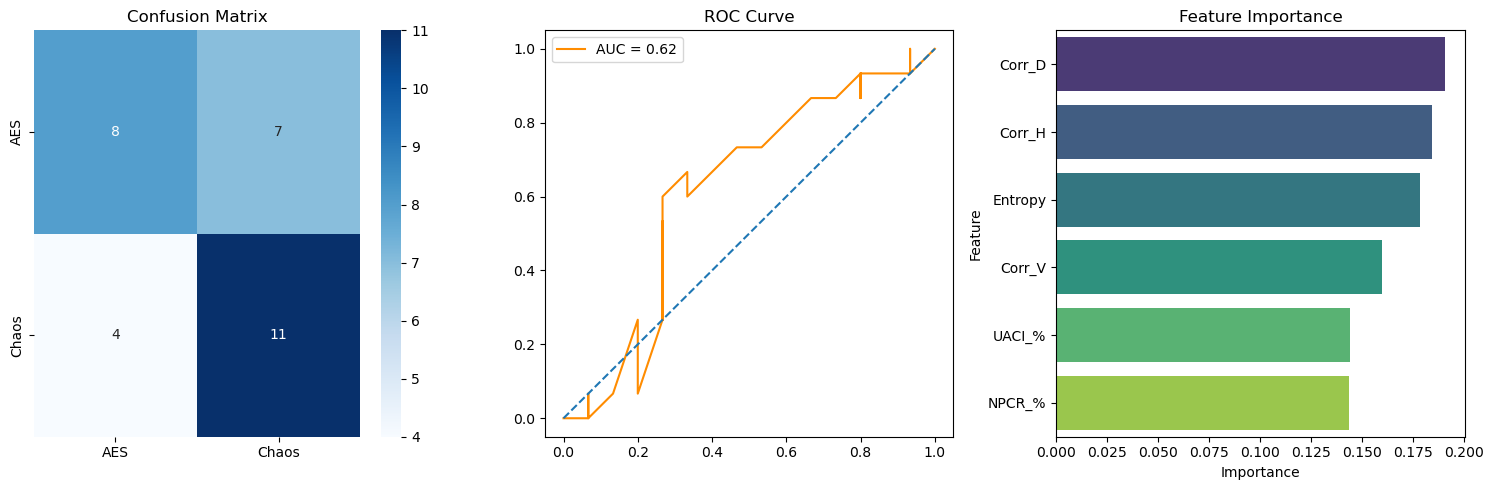

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- 1. Load Data ---
FILE_PATH = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\book512AES_chaos.xlsx"

try:
    df = pd.read_excel(FILE_PATH).dropna()
    print(f"Successfully loaded {len(df)} samples.")
except Exception as e:
    print(f"Error: {e}")
    exit()

# --- 2. Setup & Train ---
features = ['Entropy', 'Corr_H', 'Corr_V', 'Corr_D', 'NPCR_%', 'UACI_%']
X, y = df[features], df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- 3. Manual Calculations ---
y_true = np.array(y_test)
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Metrics
tp = np.sum((y_true == 1) & (y_pred == 1))
tn = np.sum((y_true == 0) & (y_pred == 0))
fp = np.sum((y_true == 0) & (y_pred == 1))
fn = np.sum((y_true == 1) & (y_pred == 0))

prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_1  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1   = 2 * (prec_1 * rec_1) / (prec_1 + rec_1) if (prec_1 + rec_1) > 0 else 0

prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
rec_0  = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_0   = 2 * (prec_0 * rec_0) / (prec_0 + rec_0) if (prec_0 + rec_0) > 0 else 0

accuracy = (tp + tn) / len(y_true)

# --- 4. Feature Importance Calculation ---
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# --- 5. ROC Curve Calculation ---
fpr_list, tpr_list = [], []
for thresh in np.linspace(0, 1, 100):
    y_p = (y_probs >= thresh).astype(int)
    t_p = np.sum((y_true == 1) & (y_p == 1))
    f_p = np.sum((y_true == 0) & (y_p == 1))
    t_n = np.sum((y_true == 0) & (y_p == 0))
    f_n = np.sum((y_true == 1) & (y_p == 0))
    tpr_list.append(t_p / (t_p + f_n) if (t_p + f_n) > 0 else 0)
    fpr_list.append(f_p / (f_p + t_n) if (f_p + t_n) > 0 else 0)

# Sort for plotting and use the updated 'trapezoid' function
sorted_idx = np.argsort(fpr_list)
fpr_arr, tpr_arr = np.array(fpr_list)[sorted_idx], np.array(tpr_list)[sorted_idx]
auc_val = np.trapezoid(tpr_arr, fpr_arr) # Fixed DeprecationWarning

# --- 6. Final Report ---
print("\n" + "="*55)
print(f"{'CLASS':<12} | {'PRECISION':<10} | {'RECALL':<10} | {'F1-SCORE':<10}")
print("-" * 55)
print(f"{'AES (0)':<12} | {prec_0:<10.4f} | {rec_0:<10.4f} | {f1_0:<10.4f}")
print(f"{'Chaos (1)':<12} | {prec_1:<10.4f} | {rec_1:<10.4f} | {f1_1:<10.4f}")
print("-" * 55)
print(f"OVERALL ACCURACY: {accuracy * 100:.2f}% | AUC: {auc_val:.4f}")
print("="*55)
print("\nFEATURE RANKING:")
print(feature_df.to_string(index=False))

# --- 7. Visualization ---
plt.figure(figsize=(15, 5))

# Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues', 
            xticklabels=['AES', 'Chaos'], yticklabels=['AES', 'Chaos'])
plt.title("Confusion Matrix")

# ROC Curve
plt.subplot(1, 3, 2)
plt.plot(fpr_arr, tpr_arr, color='darkorange', label=f'AUC = {auc_val:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.legend()

# Feature Importance
plt.subplot(1, 3, 3)
sns.barplot(x='Importance', y='Feature', data=feature_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance')

plt.tight_layout()
plt.show()

In [ ]:
"""Random forest classifer on 1024x1024 images resolution metrices"""

Successfully loaded 106 samples.

CLASS        | PRECISION  | RECALL     | F1-SCORE  
-------------------------------------------------------
AES (0)      | 0.5000     | 0.3636     | 0.4211    
Chaos (1)    | 0.5000     | 0.6364     | 0.5600    
-------------------------------------------------------
OVERALL ACCURACY: 50.00% | AUC: 0.5000

FEATURE RANKING:
Feature  Importance
 NPCR_%    0.218405
Entropy    0.178909
 Corr_D    0.166143
 Corr_H    0.147415
 UACI_%    0.146137
 Corr_V    0.142992


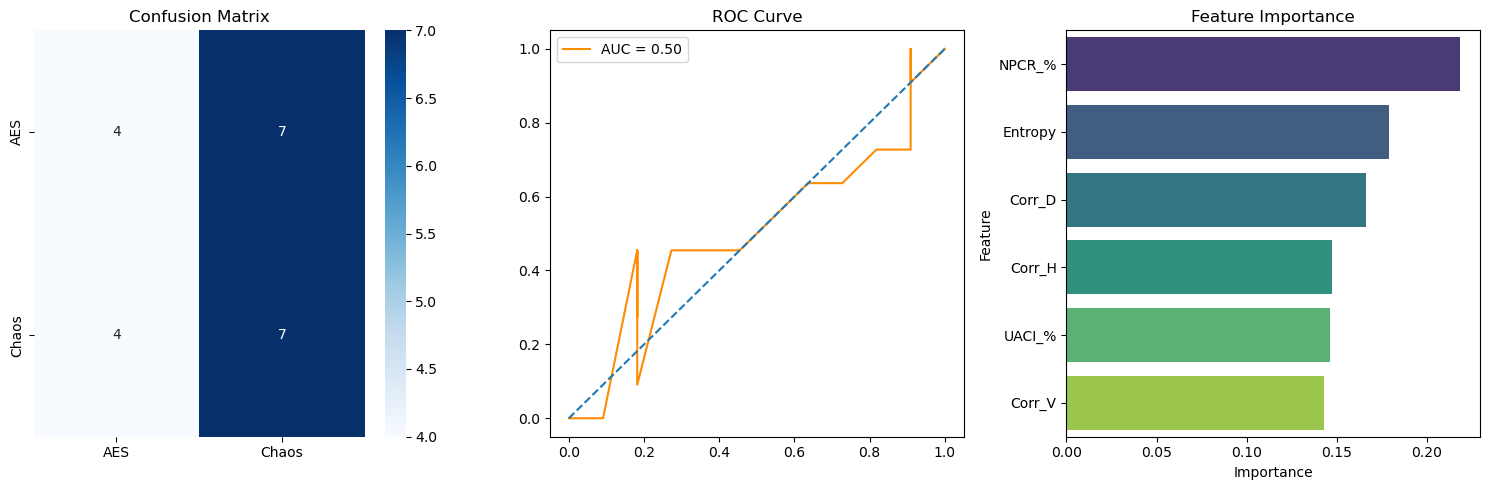

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- 1. Load Data ---
FILE_PATH = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\book1024AES_chaos.xlsx"

try:
    df = pd.read_excel(FILE_PATH).dropna()
    print(f"Successfully loaded {len(df)} samples.")
except Exception as e:
    print(f"Error: {e}")
    exit()

# --- 2. Setup & Train ---
features = ['Entropy', 'Corr_H', 'Corr_V', 'Corr_D', 'NPCR_%', 'UACI_%']
X, y = df[features], df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- 3. Manual Calculations ---
y_true = np.array(y_test)
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Metrics
tp = np.sum((y_true == 1) & (y_pred == 1))
tn = np.sum((y_true == 0) & (y_pred == 0))
fp = np.sum((y_true == 0) & (y_pred == 1))
fn = np.sum((y_true == 1) & (y_pred == 0))

prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_1  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1   = 2 * (prec_1 * rec_1) / (prec_1 + rec_1) if (prec_1 + rec_1) > 0 else 0

prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
rec_0  = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_0   = 2 * (prec_0 * rec_0) / (prec_0 + rec_0) if (prec_0 + rec_0) > 0 else 0

accuracy = (tp + tn) / len(y_true)

# --- 4. Feature Importance Calculation ---
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# --- 5. ROC Curve Calculation ---
fpr_list, tpr_list = [], []
for thresh in np.linspace(0, 1, 100):
    y_p = (y_probs >= thresh).astype(int)
    t_p = np.sum((y_true == 1) & (y_p == 1))
    f_p = np.sum((y_true == 0) & (y_p == 1))
    t_n = np.sum((y_true == 0) & (y_p == 0))
    f_n = np.sum((y_true == 1) & (y_p == 0))
    tpr_list.append(t_p / (t_p + f_n) if (t_p + f_n) > 0 else 0)
    fpr_list.append(f_p / (f_p + t_n) if (f_p + t_n) > 0 else 0)

# Sort for plotting and use the updated 'trapezoid' function
sorted_idx = np.argsort(fpr_list)
fpr_arr, tpr_arr = np.array(fpr_list)[sorted_idx], np.array(tpr_list)[sorted_idx]
auc_val = np.trapezoid(tpr_arr, fpr_arr) # Fixed DeprecationWarning

# --- 6. Final Report ---
print("\n" + "="*55)
print(f"{'CLASS':<12} | {'PRECISION':<10} | {'RECALL':<10} | {'F1-SCORE':<10}")
print("-" * 55)
print(f"{'AES (0)':<12} | {prec_0:<10.4f} | {rec_0:<10.4f} | {f1_0:<10.4f}")
print(f"{'Chaos (1)':<12} | {prec_1:<10.4f} | {rec_1:<10.4f} | {f1_1:<10.4f}")
print("-" * 55)
print(f"OVERALL ACCURACY: {accuracy * 100:.2f}% | AUC: {auc_val:.4f}")
print("="*55)
print("\nFEATURE RANKING:")
print(feature_df.to_string(index=False))

# --- 7. Visualization ---
plt.figure(figsize=(15, 5))

# Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues', 
            xticklabels=['AES', 'Chaos'], yticklabels=['AES', 'Chaos'])
plt.title("Confusion Matrix")

# ROC Curve
plt.subplot(1, 3, 2)
plt.plot(fpr_arr, tpr_arr, color='darkorange', label=f'AUC = {auc_val:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.legend()

# Feature Importance
plt.subplot(1, 3, 3)
sns.barplot(x='Importance', y='Feature', data=feature_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance')

plt.tight_layout()
plt.show()

In [ ]:
"""SVM on 512x512 images resolution metrices"""

Running GridSearchCV for SVM...
Calculating Feature Importance...

Class           | Precision  | Recall     | F1-Score  
-------------------------------------------------------
0 (AES)         | 0.60       | 0.40       | 0.48      
1 (Chaos)       | 0.55       | 0.73       | 0.63      
-------------------------------------------------------
Overall Accuracy: 56.67%
ROC-AUC Score:    0.3800

Feature Importance Rankings:
   Feature  Importance
4   NPCR_%    0.133333
0  Entropy    0.053333
5   UACI_%    0.033333
1   Corr_H    0.030000
3   Corr_D    0.000000
2   Corr_V   -0.033333


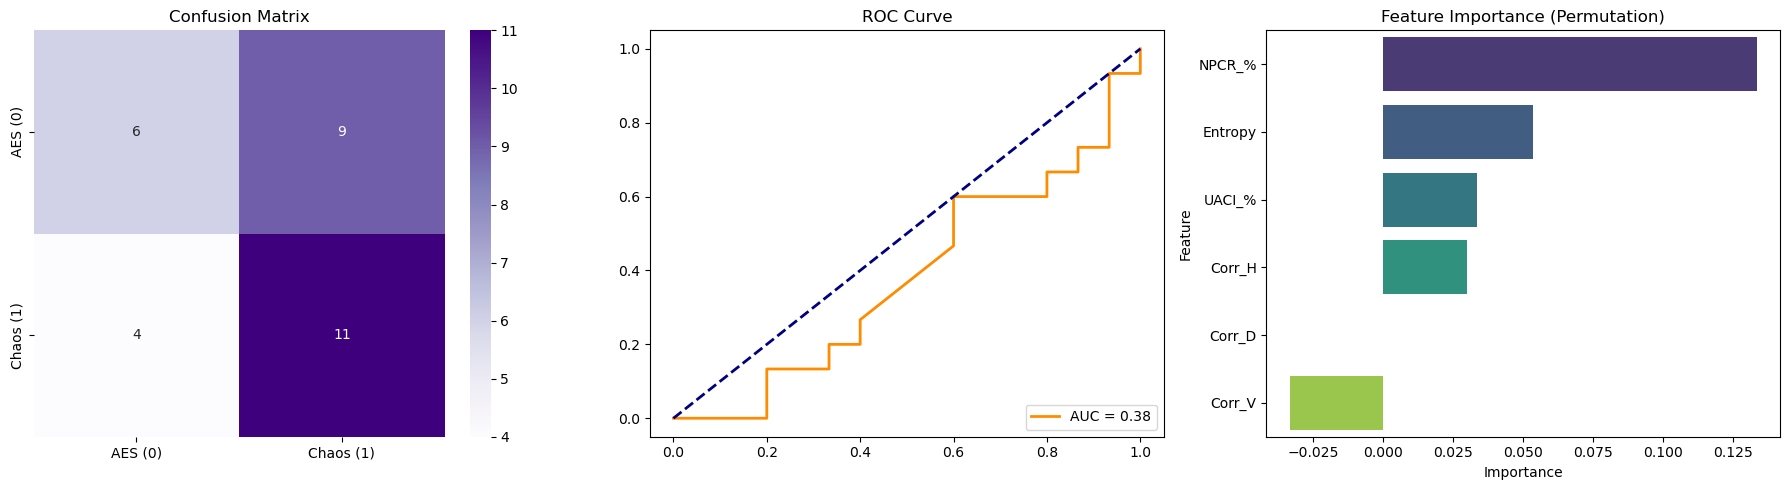

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

# 1. Load Data
file_path = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\book512AES_chaos.xlsx"
df = pd.read_excel(file_path).dropna()

# 2. Scientific Feature Selection
features = ["Entropy", "Corr_H", "Corr_V", "Corr_D", "NPCR_%", "UACI_%"]
X = df[features]
y = df["label"]

# Stratified split ensures equal distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Build the Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42))
])

# 4. Hyperparameter Tuning
# Expanded grid to help with the low AUC score
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto", 0.01, 0.1, 1]
}

print("Running GridSearchCV for SVM...")
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

# 5. Model Evaluation
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Manual Calculations
prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_1  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1   = 2 * (prec_1 * rec_1) / (prec_1 + rec_1) if (prec_1 + rec_1) > 0 else 0

prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
rec_0  = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_0   = 2 * (prec_0 * rec_0) / (prec_0 + rec_0) if (prec_0 + rec_0) > 0 else 0

overall_acc = (tp + tn) / (tp + tn + fp + fn)
roc_auc = roc_auc_score(y_test, y_prob)

# 6. Feature Importance Calculation
print("Calculating Feature Importance...")
perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# 7. Console Output
print("\n" + "="*55)
print(f"{'Class':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 55)
print(f"{'0 (AES)':<15} | {prec_0:<10.2f} | {rec_0:<10.2f} | {f1_0:<10.2f}")
print(f"{'1 (Chaos)':<15} | {prec_1:<10.2f} | {rec_1:<10.2f} | {f1_1:<10.2f}")
print("-" * 55)
print(f"Overall Accuracy: {overall_acc*100:.2f}%")
print(f"ROC-AUC Score:    {roc_auc:.4f}")
print("="*55)
print("\nFeature Importance Rankings:")
print(importance_df)

# 8. Visualizations
plt.figure(figsize=(18, 5))

# A. Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['AES (0)', 'Chaos (1)'], yticklabels=['AES (0)', 'Chaos (1)'])
plt.title("Confusion Matrix")

# B. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# C. Feature Importance Plot (Fixed FutureWarning)
plt.subplot(1, 3, 3)
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title("Feature Importance (Permutation)")

plt.tight_layout()
plt.show()

In [ ]:
"""SVM on 1024x1024 images resolution metrices"""

Running GridSearchCV for SVM...
Calculating Feature Importance...

Class           | Precision  | Recall     | F1-Score  
-------------------------------------------------------
0 (AES)         | 0.50       | 0.55       | 0.52      
1 (Chaos)       | 0.50       | 0.45       | 0.48      
-------------------------------------------------------
Overall Accuracy: 50.00%
ROC-AUC Score:    0.5207

Feature Importance Rankings:
   Feature    Importance
4   NPCR_%  5.909091e-02
2   Corr_V  3.636364e-02
3   Corr_D  1.818182e-02
1   Corr_H  1.665335e-17
0  Entropy -5.000000e-02
5   UACI_% -5.909091e-02


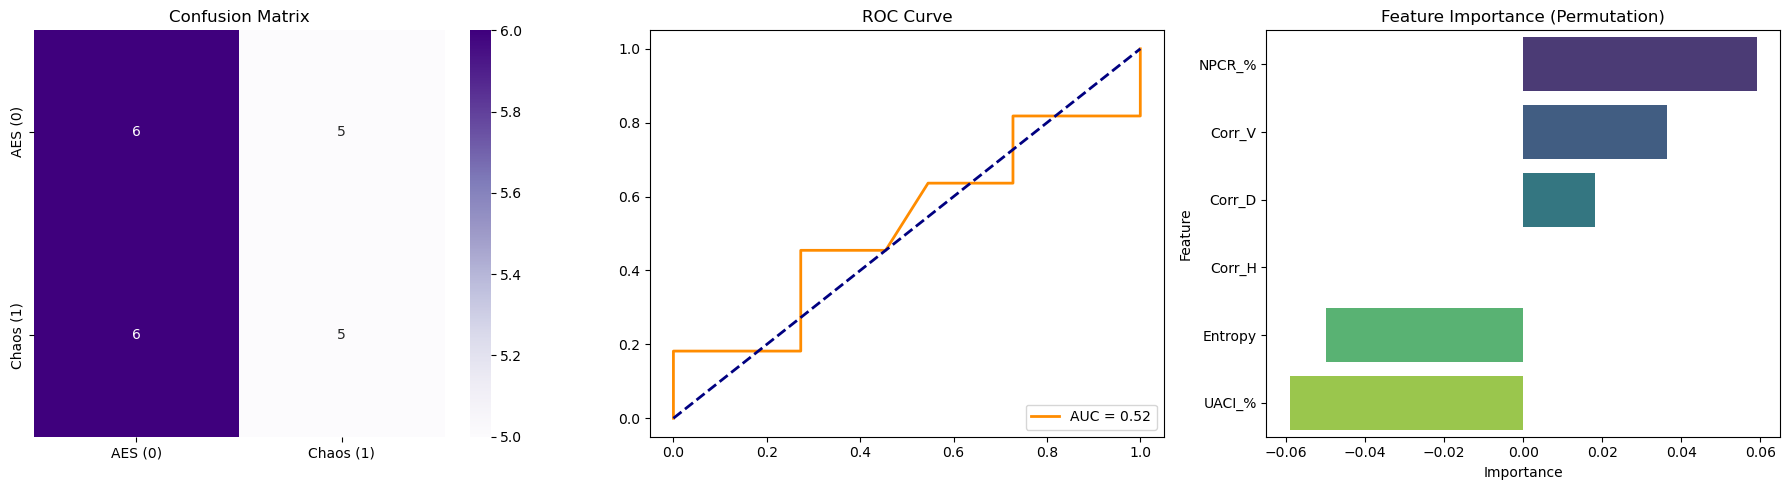

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance

# 1. Load Data
file_path = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\book1024AES_chaos.xlsx"
df = pd.read_excel(file_path).dropna()

# 2. Scientific Feature Selection
features = ["Entropy", "Corr_H", "Corr_V", "Corr_D", "NPCR_%", "UACI_%"]
X = df[features]
y = df["label"]

# Stratified split ensures equal distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Build the Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=42))
])

# 4. Hyperparameter Tuning
# Expanded grid to help with the low AUC score
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto", 0.01, 0.1, 1]
}

print("Running GridSearchCV for SVM...")
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

# 5. Model Evaluation
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Manual Calculations
prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_1  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1   = 2 * (prec_1 * rec_1) / (prec_1 + rec_1) if (prec_1 + rec_1) > 0 else 0

prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
rec_0  = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_0   = 2 * (prec_0 * rec_0) / (prec_0 + rec_0) if (prec_0 + rec_0) > 0 else 0

overall_acc = (tp + tn) / (tp + tn + fp + fn)
roc_auc = roc_auc_score(y_test, y_prob)

# 6. Feature Importance Calculation
print("Calculating Feature Importance...")
perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# 7. Console Output
print("\n" + "="*55)
print(f"{'Class':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 55)
print(f"{'0 (AES)':<15} | {prec_0:<10.2f} | {rec_0:<10.2f} | {f1_0:<10.2f}")
print(f"{'1 (Chaos)':<15} | {prec_1:<10.2f} | {rec_1:<10.2f} | {f1_1:<10.2f}")
print("-" * 55)
print(f"Overall Accuracy: {overall_acc*100:.2f}%")
print(f"ROC-AUC Score:    {roc_auc:.4f}")
print("="*55)
print("\nFeature Importance Rankings:")
print(importance_df)

# 8. Visualizations
plt.figure(figsize=(18, 5))

# A. Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['AES (0)', 'Chaos (1)'], yticklabels=['AES (0)', 'Chaos (1)'])
plt.title("Confusion Matrix")

# B. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# C. Feature Importance Plot (Fixed FutureWarning)
plt.subplot(1, 3, 3)
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title("Feature Importance (Permutation)")

plt.tight_layout()
plt.show()

In [ ]:
"""Logistic Regression on 512x512 images resolution metrices"""


Class        | Precision  | Recall     | F1-Score  
-------------------------------------------------------
0 (AES)      | 0.5833     | 0.4118     | 0.4828    
1 (Chaos)    | 0.4444     | 0.6154     | 0.5161    
-------------------------------------------------------
Overall Accuracy: 50.00%
ROC-AUC Score:    0.4977

Feature Importance (Coefficients):
Feature  Importance
 NPCR_%   -0.233826
Entropy    0.158023
 Corr_H    0.154735
 Corr_V    0.144424
 UACI_%    0.099326
 Corr_D    0.035368


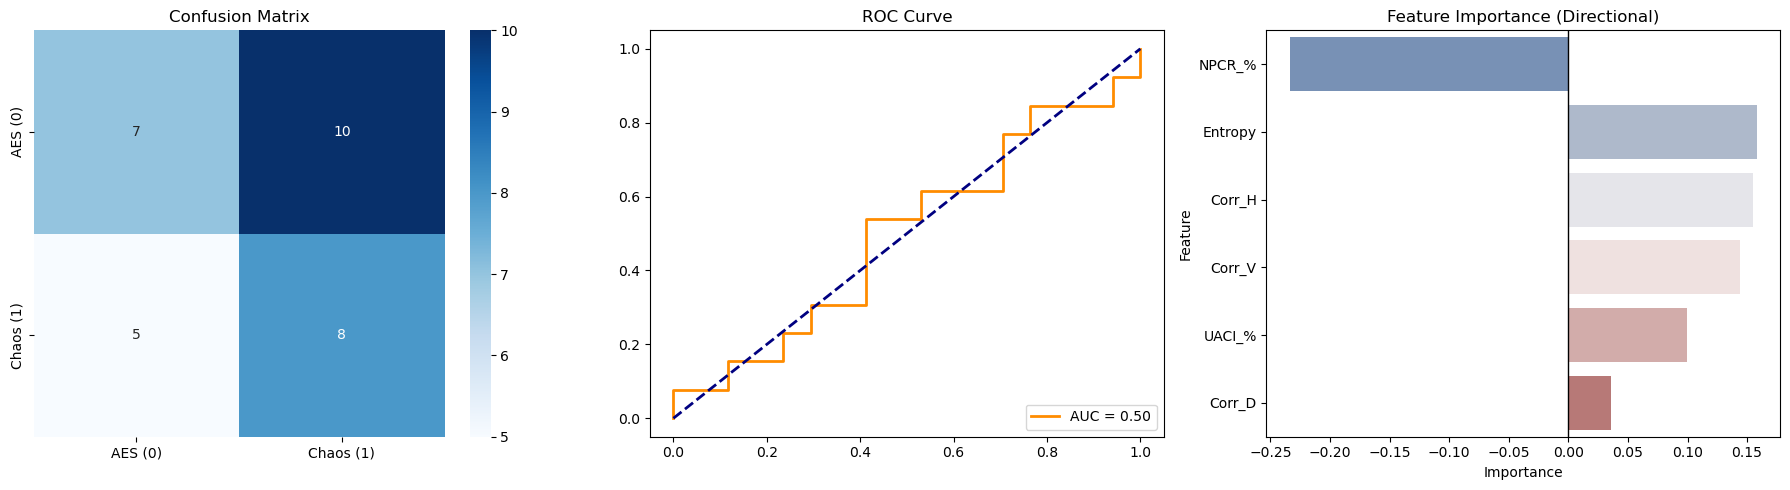

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# 1. Load the data
file_path = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\book512AES_chaos.xlsx"
df = pd.read_excel(file_path).dropna()

# 2. Preprocessing
X = df.drop(columns=['Filename', 'label'])
y = df['label']
feature_names = X.columns

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Apply Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# 6. Feature Importance Calculation
importance = lr.coef_[0]
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance,
    'Abs_Importance': np.abs(importance)
}).sort_values(by='Abs_Importance', ascending=False)

# 7. Predictions
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# 8. Manual Metric Calculations
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_1  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1   = 2 * (prec_1 * rec_1) / (prec_1 + rec_1) if (prec_1 + rec_1) > 0 else 0

prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
rec_0  = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_0   = 2 * (prec_0 * rec_0) / (prec_0 + rec_0) if (prec_0 + rec_0) > 0 else 0

accuracy = (tp + tn) / (tp + tn + fp + fn)

# 9. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 10. Print Report
print("\n" + "="*55)
print(f"{'Class':<12} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 55)
print(f"{'0 (AES)':<12} | {prec_0:<10.4f} | {rec_0:<10.4f} | {f1_0:<10.4f}")
print(f"{'1 (Chaos)':<12} | {prec_1:<10.4f} | {rec_1:<10.4f} | {f1_1:<10.4f}")
print("-" * 55)
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"ROC-AUC Score:    {roc_auc:.4f}")
print("="*55)
print("\nFeature Importance (Coefficients):")
print(feature_importance_df[['Feature', 'Importance']].to_string(index=False))

# 11. Visualizations
plt.figure(figsize=(18, 5))

# A. Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['AES (0)', 'Chaos (1)'], yticklabels=['AES (0)', 'Chaos (1)'])
plt.title('Confusion Matrix')

# B. ROC Curve
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# C. Feature Importance Plot (Corrected Syntax)
plt.subplot(1, 3, 3)
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, 
            hue='Feature', palette='vlag', legend=False)
plt.axvline(x=0, color='black', lw=1)
plt.title('Feature Importance (Directional)')

plt.tight_layout()
plt.show()

In [ ]:
"""Logistic Regression on 1024x1024 images resolution metrices"""


Class        | Precision  | Recall     | F1-Score  
-------------------------------------------------------
0 (AES)      | 0.4444     | 0.3636     | 0.4000    
1 (Chaos)    | 0.4615     | 0.5455     | 0.5000    
-------------------------------------------------------
Overall Accuracy: 45.45%
ROC-AUC Score:    0.5041

Feature Importance (Coefficients):
Feature  Importance
 NPCR_%   -0.448671
Entropy   -0.197324
 UACI_%    0.195217
 Corr_V    0.067712
 Corr_H   -0.052412
 Corr_D   -0.025448


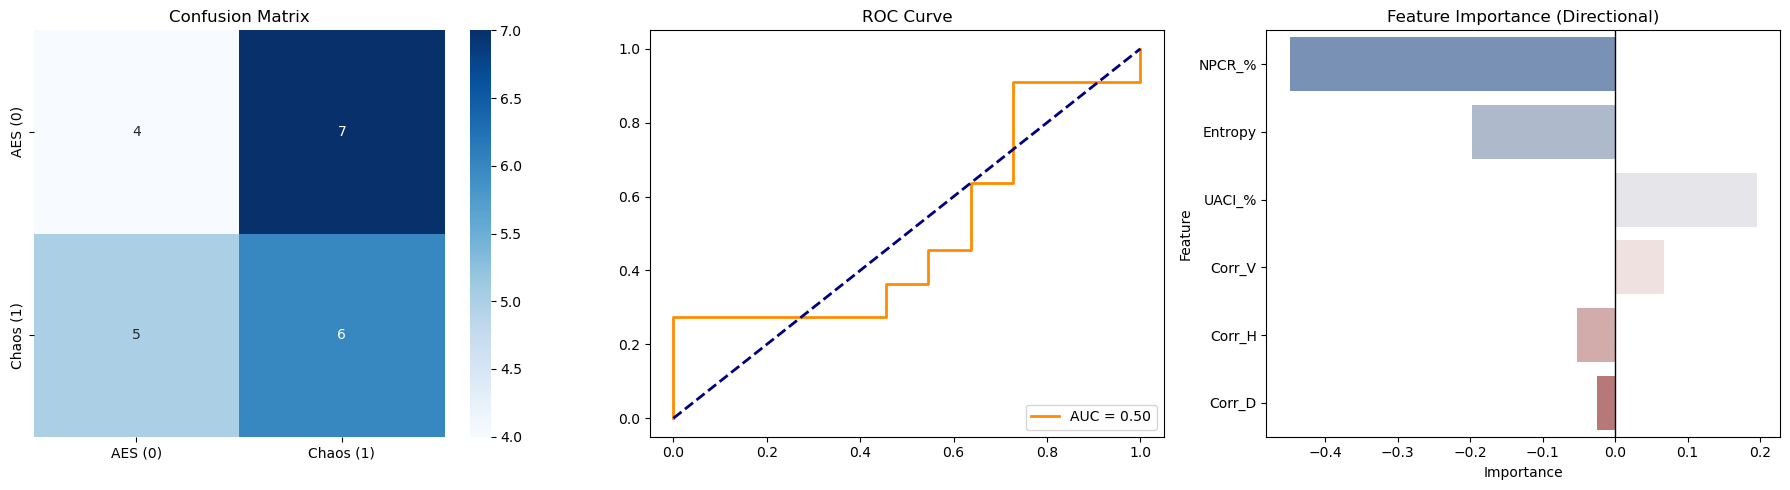

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# 1. Load the data
file_path = r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\book1024AES_chaos.xlsx"
df = pd.read_excel(file_path).dropna()

# 2. Preprocessing
X = df.drop(columns=['Filename', 'label'])
y = df['label']
feature_names = X.columns

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Apply Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# 6. Feature Importance Calculation
importance = lr.coef_[0]
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance,
    'Abs_Importance': np.abs(importance)
}).sort_values(by='Abs_Importance', ascending=False)

# 7. Predictions
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# 8. Manual Metric Calculations
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

prec_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_1  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_1   = 2 * (prec_1 * rec_1) / (prec_1 + rec_1) if (prec_1 + rec_1) > 0 else 0

prec_0 = tn / (tn + fn) if (tn + fn) > 0 else 0
rec_0  = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_0   = 2 * (prec_0 * rec_0) / (prec_0 + rec_0) if (prec_0 + rec_0) > 0 else 0

accuracy = (tp + tn) / (tp + tn + fp + fn)

# 9. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 10. Print Report
print("\n" + "="*55)
print(f"{'Class':<12} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 55)
print(f"{'0 (AES)':<12} | {prec_0:<10.4f} | {rec_0:<10.4f} | {f1_0:<10.4f}")
print(f"{'1 (Chaos)':<12} | {prec_1:<10.4f} | {rec_1:<10.4f} | {f1_1:<10.4f}")
print("-" * 55)
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"ROC-AUC Score:    {roc_auc:.4f}")
print("="*55)
print("\nFeature Importance (Coefficients):")
print(feature_importance_df[['Feature', 'Importance']].to_string(index=False))

# 11. Visualizations
plt.figure(figsize=(18, 5))

# A. Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['AES (0)', 'Chaos (1)'], yticklabels=['AES (0)', 'Chaos (1)'])
plt.title('Confusion Matrix')

# B. ROC Curve
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve')
plt.legend(loc="lower right")

# C. Feature Importance Plot (Corrected Syntax)
plt.subplot(1, 3, 3)
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, 
            hue='Feature', palette='vlag', legend=False)
plt.axvline(x=0, color='black', lw=1)
plt.title('Feature Importance (Directional)')

plt.tight_layout()
plt.show()

--- Metric Contribution Analysis ---
         LR (Abs Coeff)  RF (Importance)  SVM (Abs Coeff)
Corr_D         0.056133         0.176360         0.062006
Entropy        0.213676         0.175649         0.496388
Corr_H         0.009428         0.168635         0.012835
Corr_V         0.094476         0.164584         0.156695
NPCR_%         0.185786         0.162936         0.366048
UACI_%         0.124224         0.151837         0.160411

--- Redundancy Analysis (Correlation Matrix) ---
          Entropy    Corr_H    Corr_V    Corr_D    NPCR_%    UACI_%
Entropy  1.000000  0.025539 -0.022416 -0.042655  0.024620 -0.074273
Corr_H   0.025539  1.000000  0.022917 -0.001518 -0.038650  0.014955
Corr_V  -0.022416  0.022917  1.000000  0.033454  0.059290  0.073497
Corr_D  -0.042655 -0.001518  0.033454  1.000000 -0.104835  0.088096
NPCR_%   0.024620 -0.038650  0.059290 -0.104835  1.000000  0.057228
UACI_%  -0.074273  0.014955  0.073497  0.088096  0.057228  1.000000


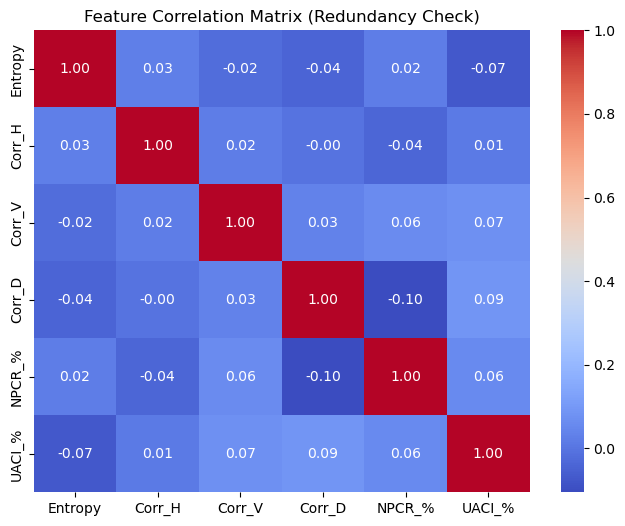

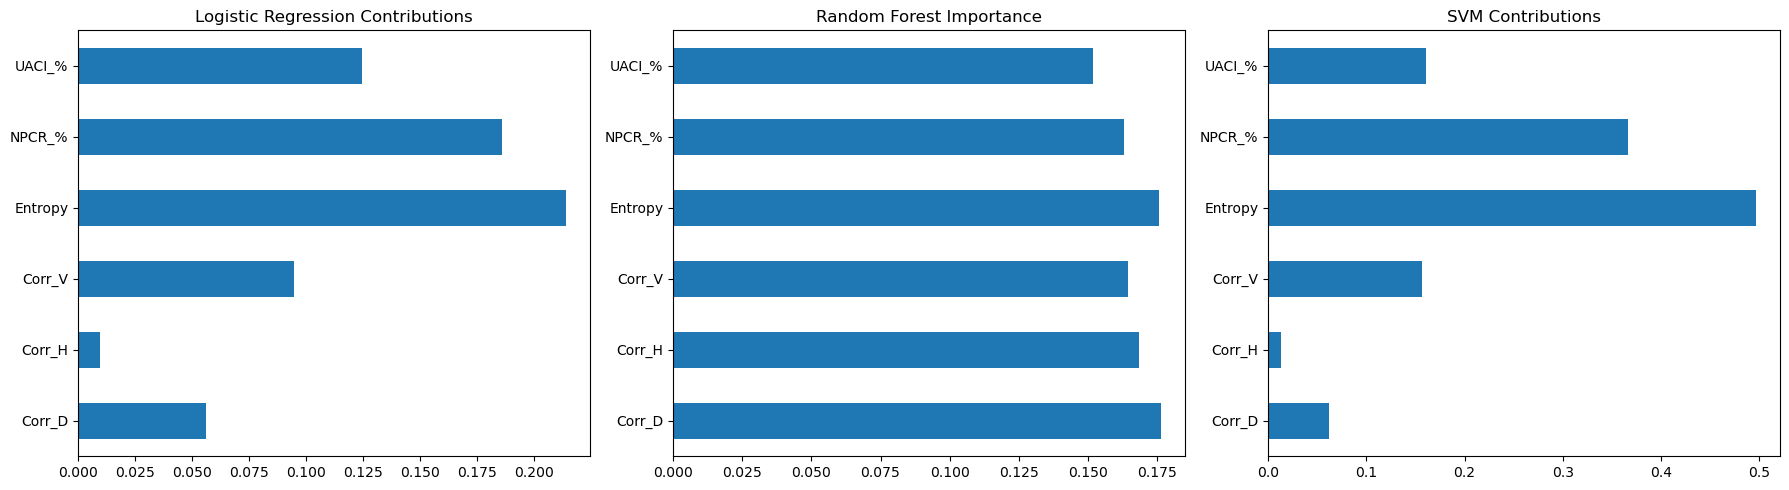

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 1. Load and Prepare Data
df = pd.read_excel(r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\book512AES_chaos.xlsx")

features = ['Entropy', 'Corr_H', 'Corr_V', 'Corr_D', 'NPCR_%', 'UACI_%']
X = df[features]
y = df['label']

# Standardize for LR and SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Metric Contribution Analysis (Model Fitting)
# Logistic Regression
lr = LogisticRegression(random_state=42).fit(X_scaled, y)
lr_coeffs = pd.Series(np.abs(lr.coef_[0]), index=features).sort_values(ascending=False)

# Random Forest
rf = RandomForestClassifier(random_state=42).fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

# SVM (Linear Kernel to extract coefficients)
svm = SVC(kernel='linear', random_state=42).fit(X_scaled, y)
svm_coeffs = pd.Series(np.abs(svm.coef_[0]), index=features).sort_values(ascending=False)

# Combine into a single Contribution Table
contribution_df = pd.DataFrame({
    'LR (Abs Coeff)': lr_coeffs,
    'RF (Importance)': rf_importances,
    'SVM (Abs Coeff)': svm_coeffs
})
print("--- Metric Contribution Analysis ---")
print(contribution_df.sort_values(by='RF (Importance)', ascending=False))

# 3. Redundancy Analysis (Correlation Matrix)
correlation_matrix = X.corr()
print("\n--- Redundancy Analysis (Correlation Matrix) ---")
print(correlation_matrix)

# Visualization of Redundancy
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix (Redundancy Check)')
plt.show()

# 5. Visualizing Metric Contributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
contribution_df['LR (Abs Coeff)'].plot(kind='barh', ax=axes[0], title='Logistic Regression Contributions')
contribution_df['RF (Importance)'].plot(kind='barh', ax=axes[1], title='Random Forest Importance')
contribution_df['SVM (Abs Coeff)'].plot(kind='barh', ax=axes[2], title='SVM Contributions')
plt.tight_layout()
plt.show()

--- Metric Contribution Analysis ---
         LR (Abs Coeff)  RF (Importance)  SVM (Abs Coeff)
NPCR_%         0.426505         0.220659         0.599420
Entropy        0.145602         0.206721         0.323843
Corr_D         0.117172         0.154094         0.147406
UACI_%         0.094663         0.141700         0.198780
Corr_V         0.085958         0.141490         0.208774
Corr_H         0.020215         0.135337         0.004066

--- Redundancy Analysis (Correlation Matrix) ---
          Entropy    Corr_H    Corr_V    Corr_D    NPCR_%    UACI_%
Entropy  1.000000  0.114863 -0.156037  0.046470 -0.009210  0.094660
Corr_H   0.114863  1.000000  0.115639  0.013559  0.059097  0.051406
Corr_V  -0.156037  0.115639  1.000000 -0.058066 -0.075913 -0.061750
Corr_D   0.046470  0.013559 -0.058066  1.000000  0.004708 -0.018707
NPCR_%  -0.009210  0.059097 -0.075913  0.004708  1.000000  0.128446
UACI_%   0.094660  0.051406 -0.061750 -0.018707  0.128446  1.000000


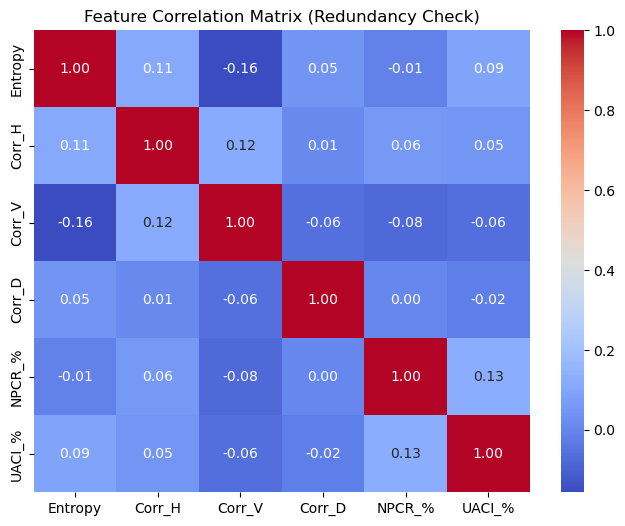

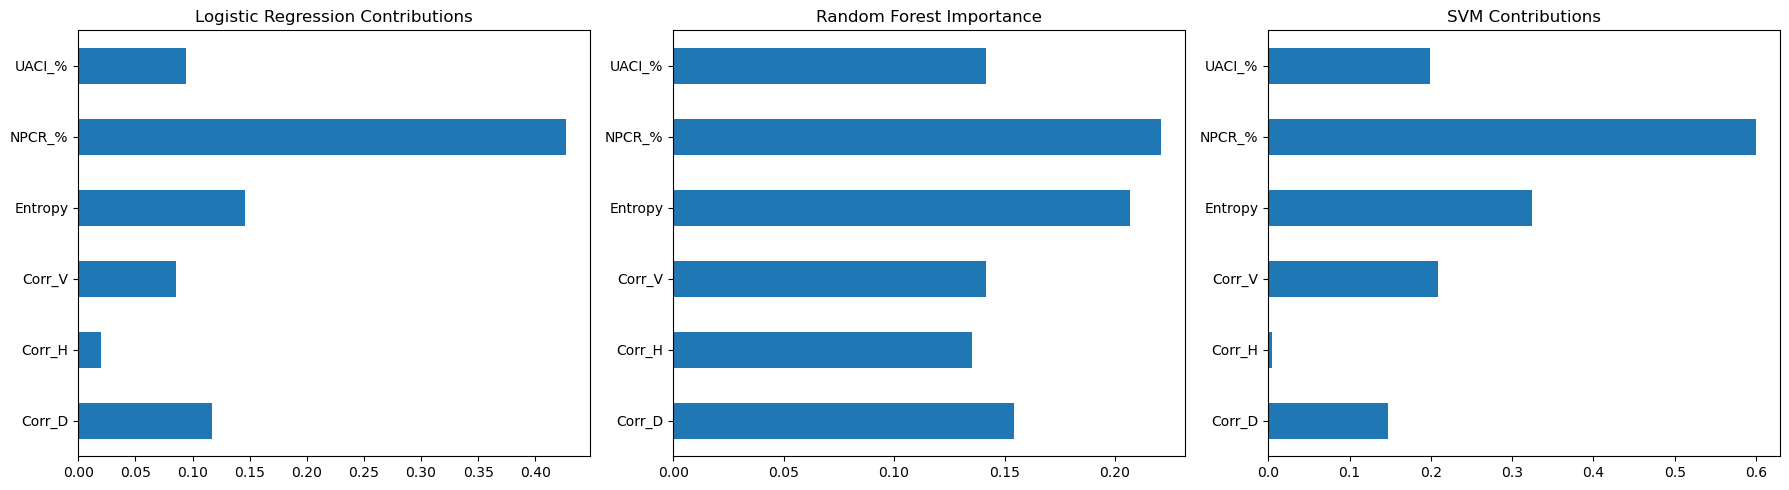

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# 1. Load and Prepare Data
df = pd.read_excel(r"C:\Class Projects\Important\NTCC_Final_Semester\JNU intership\book1024AES_chaos.xlsx")

features = ['Entropy', 'Corr_H', 'Corr_V', 'Corr_D', 'NPCR_%', 'UACI_%']
X = df[features]
y = df['label']

# Standardize for LR and SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Metric Contribution Analysis (Model Fitting)
# Logistic Regression
lr = LogisticRegression(random_state=42).fit(X_scaled, y)
lr_coeffs = pd.Series(np.abs(lr.coef_[0]), index=features).sort_values(ascending=False)

# Random Forest
rf = RandomForestClassifier(random_state=42).fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

# SVM (Linear Kernel to extract coefficients)
svm = SVC(kernel='linear', random_state=42).fit(X_scaled, y)
svm_coeffs = pd.Series(np.abs(svm.coef_[0]), index=features).sort_values(ascending=False)

# Combine into a single Contribution Table
contribution_df = pd.DataFrame({
    'LR (Abs Coeff)': lr_coeffs,
    'RF (Importance)': rf_importances,
    'SVM (Abs Coeff)': svm_coeffs
})
print("--- Metric Contribution Analysis ---")
print(contribution_df.sort_values(by='RF (Importance)', ascending=False))

# 3. Redundancy Analysis (Correlation Matrix)
correlation_matrix = X.corr()
print("\n--- Redundancy Analysis (Correlation Matrix) ---")
print(correlation_matrix)

# Visualization of Redundancy
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix (Redundancy Check)')
plt.show()

# 5. Visualizing Metric Contributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
contribution_df['LR (Abs Coeff)'].plot(kind='barh', ax=axes[0], title='Logistic Regression Contributions')
contribution_df['RF (Importance)'].plot(kind='barh', ax=axes[1], title='Random Forest Importance')
contribution_df['SVM (Abs Coeff)'].plot(kind='barh', ax=axes[2], title='SVM Contributions')
plt.tight_layout()
plt.show()